In [1]:
# ======================================
# IMPORT LIBRARIES
# ======================================

In [45]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from scipy.stats import zscore

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

!pip install catboost
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings("ignore")

In [4]:
# ======================================
# LOAD DATASET
# ======================================

In [40]:
df = pd.read_csv("water_dataX.csv", encoding="unicode_escape")

df.rename(columns={
    'STATION CODE': 'Station_Code',
    'LOCATIONS': 'Location',
    'STATE': 'State',
    'D.O. (mg/l)': 'Dissolved_Oxygen',
    'PH': 'pH',
    'CONDUCTIVITY (µmhos/cm)': 'Conductivity',
    'B.O.D. (mg/l)': 'Biological_Oxygen_Demand',
    'NITRATENAN N+ NITRITENANN (mg/l)': 'Nitrate_Nitrite',
    'FECAL COLIFORM (MPN/100ml)': 'Fecal_Coliform',
    'TOTAL COLIFORM (MPN/100ml)Mean': 'Total_Coliform'
}, inplace=True)

# Identify measurement columns that should be converted to numeric
# Exclude 'Station_Code', 'Location', 'State' from numeric conversion
measurement_cols = [
    'Temp', 'Dissolved_Oxygen', 'pH', 'Conductivity', 'Biological_Oxygen_Demand',
    'Nitrate_Nitrite', 'Fecal_Coliform', 'Total_Coliform', 'year'
]

for col in measurement_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Impute missing numeric values using median for measurement columns
imputer = SimpleImputer(strategy="median")
df[measurement_cols] = imputer.fit_transform(df[measurement_cols])

# Remove outliers using the Z-score method for measurement columns
z_scores = np.abs(zscore(df[measurement_cols]))
df = df[(z_scores < 3).all(axis=1)]

print(df.shape)
df.head()

(1818, 12)


,Station_Code,Location,State,Temp,Dissolved_Oxygen,pH,Conductivity,Biological_Oxygen_Demand,Nitrate_Nitrite,Fecal_Coliform,Total_Coliform,year
0,1393,"DAMANGANGA AT D/S OF MADHUBAN, DAMAN",DAMAN & DIU,30.6,6.7,7.5,203.0,1.8965,0.1,11.0,27.0,2014.0
1,1399,ZUARI AT D/S OF PT. WHERE KUMBARJRIA CANAL JOI...,GOA,29.8,5.7,7.2,189.0,2.0000,0.2,4953.0,8391.0,2014.0
2,1475,ZUARI AT PANCHAWADI,GOA,29.5,6.3,6.9,179.0,1.7000,0.1,3243.0,5330.0,2014.0
3,3181,RIVER ZUARI AT BORIM BRIDGE,GOA,29.7,5.8,6.9,64.0,3.8000,0.5,5382.0,8443.0,2014.0
4,3182,RIVER ZUARI AT MARCAIM JETTY,GOA,29.5,5.8,7.3,83.0,1.9000,0.4,3428.0,5500.0,2014.0


In [75]:
# ============================================================
# STATE & LOCATION CLEANING / ENRICHMENT
# ============================================================

import pandas as pd
import numpy as np

# Standardize column names
df.rename(columns={
    'STATION CODE': 'Station_Code',
    'LOCATIONS': 'Location',
    'STATE': 'State',
    'DO': 'Dissolved_Oxygen',
    'BOD': 'Biological_Oxygen_Demand',
    'NITRATENAN N+ NITRITENANN (mg/l)': 'Nitrate_Nitrite',
    'Fec_col': 'Fecal_Coliform',
    'TOTAL COLIFORM (MPN/100ml)Mean': 'Total_Coliform'
}, inplace=True)

# ------------------------------------------------------------
# Extract State from Location when State is missing
# Example:
# "IRUPANAM, KERALA" -> Kerala
# "AMBIKA AT BILIMORA, GUJARAT" -> Gujarat
# ------------------------------------------------------------

def extract_state(location):
    if pd.isna(location):
        return np.nan

    location = str(location).strip()

    if "," in location:
        state = location.split(",")[-1].strip().title()
        return state

    return np.nan

# Fill missing states
df["State"] = df["State"].fillna(
    df["Location"].apply(extract_state)
)

# ------------------------------------------------------------
# Create clean location column
# Example:
# "IRUPANAM, KERALA" -> "IRUPANAM"
# ------------------------------------------------------------

def clean_location(location):
    if pd.isna(location):
        return np.nan

    return str(location).split(",")[0].strip().title()

df["Clean_Location"] = df["Location"].apply(clean_location)

# ------------------------------------------------------------
# Standardize State names
# ------------------------------------------------------------

df["State"] = (
    df["State"]
    .astype(str)
    .str.strip()
    .str.title()
)

# Fix common state name inconsistencies
state_mapping = {
    "Tamilnadu": "Tamil Nadu",
    "Uttarpradesh": "Uttar Pradesh",
    "Madhyapradesh": "Madhya Pradesh",
    "Andhrapradesh": "Andhra Pradesh",
    "Westbengal": "West Bengal",
    "Jammu & Kashmir": "Jammu and Kashmir"
}

df["State"] = df["State"].replace(state_mapping)

# ------------------------------------------------------------
# Quality Checks
# ------------------------------------------------------------

print("="*60)
print("DATA CLEANING SUMMARY")
print("="*60)

print(f"Total Records: {len(df)}")
print(f"Missing States: {df['State'].isna().sum()}")
print(f"Unique States: {df['State'].nunique()}")
print(f"Unique Locations: {df['Clean_Location'].nunique()}")

print("\nSample Records:")
display(
    df[
        ['Clean_Location', 'State']
    ].sample(10, random_state=42)
)

print("\nTop 10 States by Record Count:")
display(
    df['State']
    .value_counts()
    .head(10)
)

print("\nState Missing Check:")
display(
    df[df['State'].isna()][['Location']]
    .head(20)
)

DATA CLEANING SUMMARY
Total Records: 1818
Missing States: 0
Unique States: 178
Unique Locations: 473

Sample Records:


,Clean_Location,State
1929,Chaliyar At Koolimadu,Nan
1073,Patalganga At Shilphata,Nan
143,Netravathi U/S Of Dharmastala At Water Supply ...,Karnataka
434,Ghaggar Near Bankarpur,Punjab
633,River Periyar At Pathalam,Kerala
1902,Zuari At D/S Of Pt. Where Kumbarjria Canal Joins,Nan
308,Savitri River At Ovale Village.,Maharashtra
863,Tansa River Near Road Bridge,Maharashtra
1688,Bhadar D/S Jetpur Vill. After Conf. Of W.Water...,Nan
1279,Nan,"Pamba At Thakazhy, Kerala"



Top 10 States by Record Count:


,count
State,
Nan,694
Kerala,251
Maharashtra,137
Meghalaya,111
Goa,99
Manipur,73
Tamil Nadu,41
Punjab,40
Gujarat,29



State Missing Check:


,Location


In [39]:
df.rename(columns={
    'STATION CODE': 'Station_Code',
    'LOCATIONS': 'Location',
    'STATE': 'State',
    'DO': 'Dissolved_Oxygen',
    'BOD': 'Biological_Oxygen_Demand',
    'NITRATENAN N+ NITRITENANN (mg/l)': 'Nitrate_Nitrite',
    'Fec_col': 'Fecal_Coliform',
    'TOTAL COLIFORM (MPN/100ml)Mean': 'Total_Coliform'
}, inplace=True)

In [11]:
wi = np.array([
    0.2213,
    0.2604,
    0.0022
])

si = np.array([
    10,
    8.5,
    1000
])

vIdeal = np.array([
    14.6,
    7,
    0
])

In [41]:
def classify_wqi(x):

    if x <= 25:
        return 4

    elif x <= 50:
        return 3

    elif x <= 75:
        return 2

    elif x <= 100:
        return 1

    else:
        return 0

# Calculate qn for DO, pH, Conductivity using updated column names
# Assuming wi, si, vIdeal are defined in a previous cell
# and are used for 'Dissolved_Oxygen', 'pH', 'Conductivity' respectively.
qn_do = ((df['Dissolved_Oxygen'] - vIdeal[0]) / (si[0] - vIdeal[0])) * 100
qn_ph = ((df['pH'] - vIdeal[1]) / (si[1] - vIdeal[1])) * 100
qn_cond = ((df['Conductivity'] - vIdeal[2]) / (si[2] - vIdeal[2])) * 100

# Calculate WQI
df['WQI'] = (wi[0] * qn_do + wi[1] * qn_ph + wi[2] * qn_cond) / np.sum(wi)

df["WQI_Class"] = df["WQI"].apply(
    classify_wqi
)

### Exploring Water Quality Index (WQI) by State and Year

In [47]:
# State-wise Water Quality
df_wqi_state = df.groupby("State")["WQI"].mean().sort_values(ascending=False)
print("Average WQI by State (lower is better):\n", df_wqi_state)

Average WQI by State (lower is better):
 State
NAN                                                                        1444.589684
RIVER BHOGAVO D/S OF SURENDRANAGAR.                                         168.142744
MINDHOLA AT STATE HIGHWAY BRIDGE SACHIN, GUJARAT                            146.855267
RIVER PURNA ON BRIDGE AT SURATNANNAVSARI HIGHWAY                            145.404564
BHADAR D/S JETPUR VILL. AFTER CONF. OF W.WATER FROM JETPUR CITY,GUJARAT     144.343817
                                                                              ...     
R THALLASSERY AT PATHIPPALAM                                                 49.263836
RIVER VALVANT AT SANKLI NAN BICHOLIM, GOA                                    46.356464
RIVER MADAI AT DABOS NAN  VALPOI, GOA                                        46.120506
R PERUVAMBA AT CHANDAPPURA                                                   43.898673
PERIYAR NEAR ALWAYENANELOOR, KERALA                                          40.152

In [48]:
# Year-wise Trend
df_wqi_year = df.groupby("year")["WQI"].mean()
print("\nAverage WQI by Year:\n", df_wqi_year)


Average WQI by Year:
 year
2003.0    11560.729989
2004.0    12033.471714
2005.0       88.465558
2006.0       92.185838
2007.0       87.760636
2008.0       85.936604
2009.0       87.741694
2010.0       87.829220
2011.0       91.717442
2012.0       88.328871
2013.0       88.184915
2014.0       89.033145
Name: WQI, dtype: float64


In [49]:
# Top Polluted Locations (Highest WQI)
# Displaying the top 10 locations with the highest WQI
df_top_polluted = df.sort_values("WQI", ascending=False).head(10)
print("\nTop 10 Most Polluted Locations (Highest WQI):\n")
display(df_top_polluted[['Location', 'State', 'WQI']])


Top 10 Most Polluted Locations (Highest WQI):



,Location,State,WQI
1953,"IRUPANAM, KERALA",NAN,121231.016444
1936,"PAMBA AT KALLOOPARA, KERALA",NAN,65656.385604
1919,"AMBIKA AT BILIMORA, GUJARAT",NAN,61089.302449
1926,"PERIYAR AT ALWAYE, KERALA",NAN,56477.310201
1918,RIVER DHADAR AT KOTHADA,NAN,46597.716315
1920,"KOLAK AT PATALIA BDG., GUJARAT",NAN,41972.801050
1923,BHADAR D/S JETPUR VILL. AFTER CONF. OF W.WATER...,NAN,41002.182385
1978,"ARASALAR RIVER KARAIKAL REGION, PONDICHERRY",NAN,34900.419358
1986,"TAMBIRAPARANI AT ARUMUGANERI, TAMILNADU",NAN,26291.370965
1924,"MINDHOLA AT STATE HIGHWAY BRIDGE SACHIN, GUJARAT",NAN,20980.848926


In [86]:
# Re-executing all cells from data loading to WQI analysis to apply the fixes.

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from scipy.stats import zscore

# --- Data Loading and Initial Renaming (from GkUVg1_4L3KO) ---
df = pd.read_csv("water_dataX.csv", encoding="unicode_escape")

df.rename(columns={
    'STATION CODE': 'Station_Code',
    'LOCATIONS': 'Location',
    'STATE': 'State',
    'D.O. (mg/l)': 'Dissolved_Oxygen',
    'PH': 'pH',
    'CONDUCTIVITY (µmhos/cm)': 'Conductivity',
    'B.O.D. (mg/l)': 'Biological_Oxygen_Demand',
    'NITRATENAN N+ NITRITENANN (mg/l)': 'Nitrate_Nitrite',
    'FECAL COLIFORM (MPN/100ml)': 'Fecal_Coliform',
    'TOTAL COLIFORM (MPN/100ml)Mean': 'Total_Coliform'
}, inplace=True)

# Identify measurement columns that should be converted to numeric
measurement_cols = [
    'Temp', 'Dissolved_Oxygen', 'pH', 'Conductivity', 'Biological_Oxygen_Demand',
    'Nitrate_Nitrite', 'Fecal_Coliform', 'Total_Coliform', 'year'
]

for col in measurement_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Impute missing numeric values using median for measurement columns
imputer = SimpleImputer(strategy="median")
df[measurement_cols] = imputer.fit_transform(df[measurement_cols])

# Remove outliers using the Z-score method for measurement columns
z_scores = np.abs(zscore(df[measurement_cols]))
df = df[(z_scores < 3).all(axis=1)]

# --- State & Location Cleaning / Enrichment (from yRmtIi7CMK7a) ---
def extract_state(location):
    if pd.isna(location):
        return np.nan
    location = str(location).strip()
    if "," in location:
        state = location.split(",")[-1].strip().title()
        return state
    return np.nan

df["State"] = df["State"].fillna(
    df["Location"].apply(extract_state)
)

def clean_location(location):
    if pd.isna(location):
        return np.nan
    return str(location).split(",")[0].strip().title()

df["Clean_Location"] = df["Location"].apply(clean_location)

df["State"] = (
    df["State"]
    .astype(str)
    .str.strip()
    .str.title()
)

state_mapping = {
    "Tamilnadu": "Tamil Nadu",
    "Uttarpradesh": "Uttar Pradesh",
    "Madhyapradesh": "Madhya Pradesh",
    "Andhrapradesh": "Andhra Pradesh",
    "Westbengal": "West Bengal",
    "Jammu & Kashmir": "Jammu and Kashmir"
}
df["State"] = df["State"].replace(state_mapping)

# --- WQI Calculation (from uvJBBeeIMV-V and f3B7bZ0NMX-i) ---
wi = np.array([0.2213, 0.2604, 0.0022])
si = np.array([10, 8.5, 1000])
vIdeal = np.array([14.6, 7, 0])

def classify_wqi(x):
    if x <= 25:
        return 4
    elif x <= 50:
        return 3
    elif x <= 75:
        return 2
    elif x <= 100:
        return 1
    else:
        return 0

qn_do = ((df['Dissolved_Oxygen'] - vIdeal[0]) / (si[0] - vIdeal[0])) * 100
qn_ph = ((df['pH'] - vIdeal[1]) / (si[1] - vIdeal[1])) * 100
qn_cond = ((df['Conductivity'] - vIdeal[2]) / (si[2] - vIdeal[2])) * 100

df['WQI'] = (wi[0] * qn_do + wi[1] * qn_ph + wi[2] * qn_cond) / np.sum(wi)
df["WQI_Class"] = df["WQI"].apply(classify_wqi)

print("Data preprocessing and WQI calculation complete. df is now in a processed state.")
print(f"Shape of df: {df.shape}")
print(df.head())

Data preprocessing and WQI calculation complete. df is now in a processed state.
Shape of df: (1818, 15)
  Station_Code                                           Location  \
0         1393               DAMANGANGA AT D/S OF MADHUBAN, DAMAN   
1         1399  ZUARI AT D/S OF PT. WHERE KUMBARJRIA CANAL JOI...   
2         1475                                ZUARI AT PANCHAWADI   
3         3181                        RIVER ZUARI AT BORIM BRIDGE   
4         3182                       RIVER ZUARI AT MARCAIM JETTY   

         State  Temp  Dissolved_Oxygen   pH  Conductivity  \
0  Daman & Diu  30.6               6.7  7.5         203.0   
1          Goa  29.8               5.7  7.2         189.0   
2          Goa  29.5               6.3  6.9         179.0   
3          Goa  29.7               5.8  6.9          64.0   
4          Goa  29.5               5.8  7.3          83.0   

   Biological_Oxygen_Demand  Nitrate_Nitrite  Fecal_Coliform  Total_Coliform  \
0                    1.8965      

In [57]:
feature_cols = [
    "Temp",
    "Biological_Oxygen_Demand",
    "Fecal_Coliform",
    "Total_Coliform",
    "Nitrate_Nitrite"
]

X = df[feature_cols]

y = df["WQI_Class"]

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [59]:
imputer_for_split_data = SimpleImputer(strategy='median')

X_train = imputer_for_split_data.fit_transform(X_train)
X_test = imputer_for_split_data.transform(X_test)

# Identify columns with zero standard deviation in X_train
std_devs = np.std(X_train, axis=0)
# Indices of columns that have non-zero standard deviation
non_zero_std_cols_indices = np.where(std_devs != 0)[0]

# Filter X_train and X_test to keep only columns with non-zero standard deviation
X_train = X_train[:, non_zero_std_cols_indices]
X_test = X_test[:, non_zero_std_cols_indices]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [60]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            eval_metric="mlogloss",
            random_state=42
        ),

    "LightGBM":
        LGBMClassifier(
            random_state=42
        ),

    "CatBoost":
        CatBoostClassifier(
            verbose=0,
            random_state=42
        )
}

In [61]:
results = []

In [73]:
for name, model in models.items():

    if name == "Logistic Regression":

        model.fit(
            X_train_scaled,
            y_train
        )

        pred = model.predict(
            X_test_scaled
        )
        pred_proba = model.predict_proba(X_test_scaled)

    else:

        model.fit(
            X_train,
            y_train
        )

        pred = model.predict(
            X_test
        )
        pred_proba = model.predict_proba(X_test)

    print(f"\nClassification Report for {name}:\n")
    print(
        classification_report(
            y_test,
            pred
        )
    )

    # Binarize y_test for multiclass ROC-AUC calculation
    y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))

    # Calculate ROC-AUC for multiclass (weighted average)
    roc_auc = roc_auc_score(y_test_binarized, pred_proba, average='weighted', multi_class='ovr')

    results.append({

        "Model": name,

        "Accuracy":
            accuracy_score(
                y_test,
                pred
            ),

        "Precision":
            precision_score(
                y_test,
                pred,
                average="weighted"
            ),

        "Recall":
            recall_score(
                y_test,
                pred,
                average="weighted"
            ),

        "F1":
            f1_score(
                y_test,
                pred,
                average="weighted"
            ),
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(
    results
)

results_df.sort_values(
    "Accuracy",
    ascending=False
)


Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.65      0.43      0.52       135
           1       0.39      0.74      0.51       137
           2       0.27      0.05      0.08        81
           3       0.00      0.00      0.00         8
           4       0.00      0.00      0.00         3

    accuracy                           0.45       364
   macro avg       0.26      0.24      0.22       364
weighted avg       0.45      0.45      0.40       364


Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.69      0.73      0.71       135
           1       0.56      0.61      0.58       137
           2       0.58      0.48      0.53        81
           3       0.33      0.12      0.18         8
           4       1.00      0.33      0.50         3

    accuracy                           0.61       364
   macro avg       0.63      0.46      

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Random Forest,0.612637,0.609736,0.612637,0.607054,0.819995
6,Random Forest,0.612637,0.609736,0.612637,0.607054,0.819995
8,LightGBM,0.609890,0.593776,0.609890,0.600655,0.802189
2,XGBoost,0.609890,0.606948,0.609890,0.604179,0.791940
7,XGBoost,0.609890,0.606948,0.609890,0.604179,0.791940
3,LightGBM,0.609890,0.593776,0.609890,0.600655,0.802189
9,CatBoost,0.604396,0.597711,0.604396,0.598604,0.813095
4,CatBoost,0.604396,0.597711,0.604396,0.598604,0.813095
0,Logistic Regression,0.447802,0.447808,0.447802,0.402595,0.668688
5,Logistic Regression,0.447802,0.447808,0.447802,0.402595,0.668688


In [65]:
best_model_name = results_df.sort_values(
    "F1",
    ascending=False
).iloc[0]["Model"]

print(f"Best model based on F1 score: {best_model_name}")

best_model = models[best_model_name] # Get the untrained model instance

# Train the best model instance with appropriate data
if best_model_name == "Logistic Regression":
    best_model.fit(X_train_scaled, y_train)
else:
    best_model.fit(X_train, y_train)

# Calculate feature importance
# This assumes the selected best model has a .feature_importances_ attribute.
# For Logistic Regression, one would typically look at .coef_.
# Given the current F1 scores, a tree-based model (Random Forest) will be selected,
# which has this attribute.
importance = pd.DataFrame({
    "Feature":
        X.columns,

    "Importance":
        best_model.feature_importances_
})

importance.sort_values(
    "Importance",
    ascending=True
)

Best model based on F1 score: Random Forest


,Feature,Importance
0,Temp,0.165131
4,Nitrate_Nitrite,0.170912
1,Biological_Oxygen_Demand,0.217642
3,Total_Coliform,0.222159
2,Fecal_Coliform,0.224157


In [64]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="f1_weighted"
)

print("Cross-validation F1-weighted scores:", scores)
print("Mean Cross-validation F1-weighted score:", scores.mean())

Cross-validation F1-weighted scores: [0.46015067 0.52874068 0.4586369  0.48343415 0.50519489]
Mean Cross-validation F1-weighted score: 0.48723146078010177


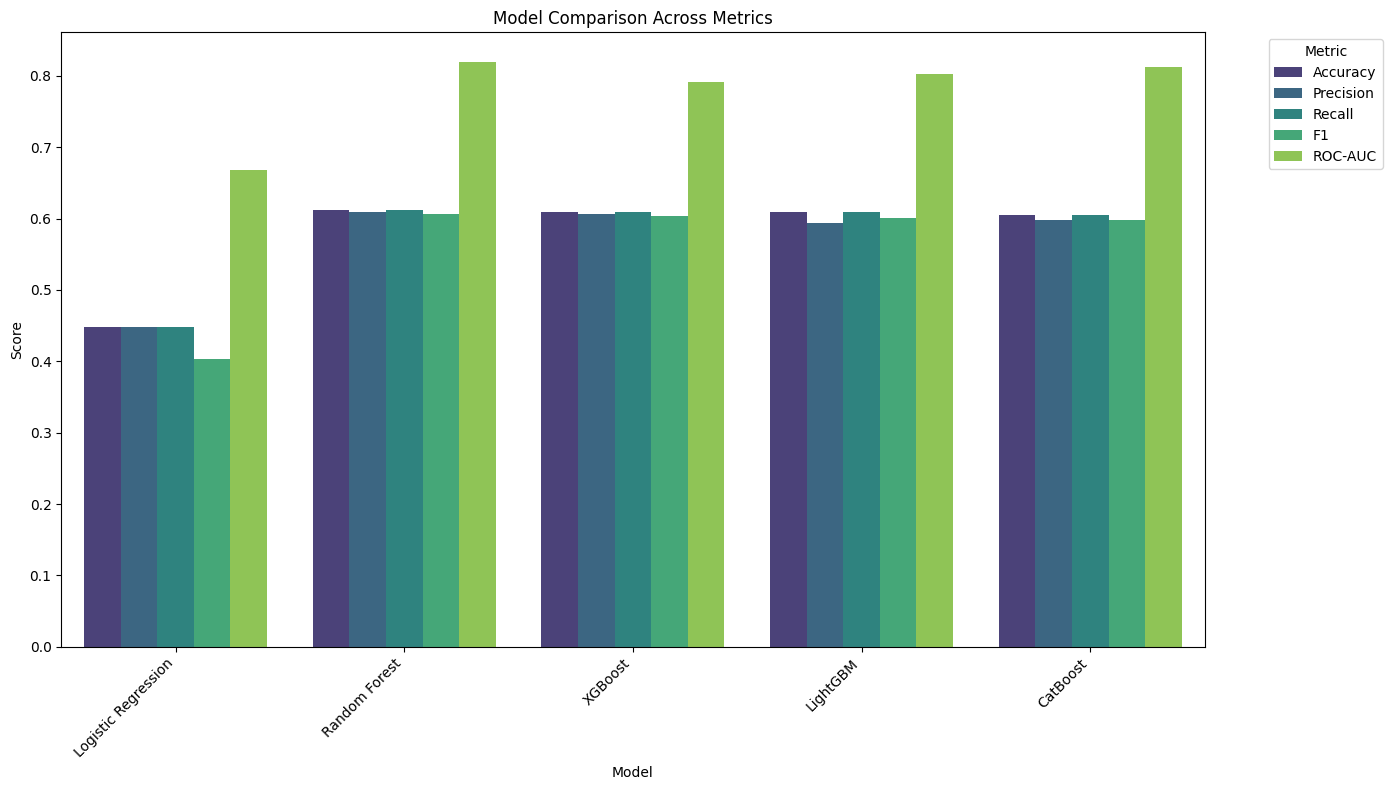

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Model Comparison Dashboard (Grouped Bar Chart)
plt.figure(figsize=(14, 8))
results_df_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score',
                                    value_vars=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])
sns.barplot(x='Model', y='Score', hue='Metric', data=results_df_melted, palette='viridis')
plt.title('Model Comparison Across Metrics')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

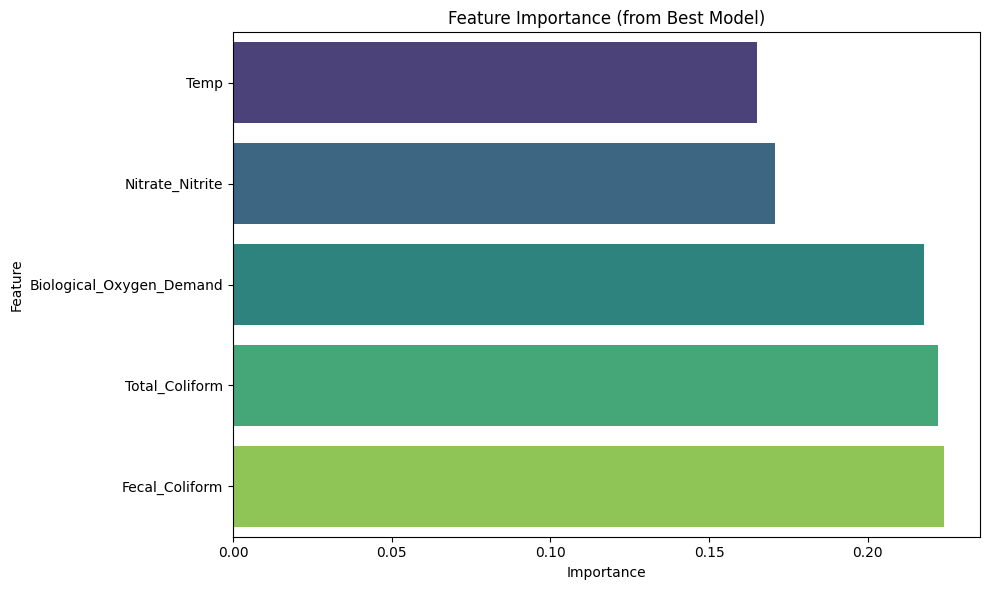

In [67]:
# 2. Feature Importance (Horizontal Bar Chart)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance.sort_values('Importance', ascending=True), palette='viridis')
plt.title('Feature Importance (from Best Model)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

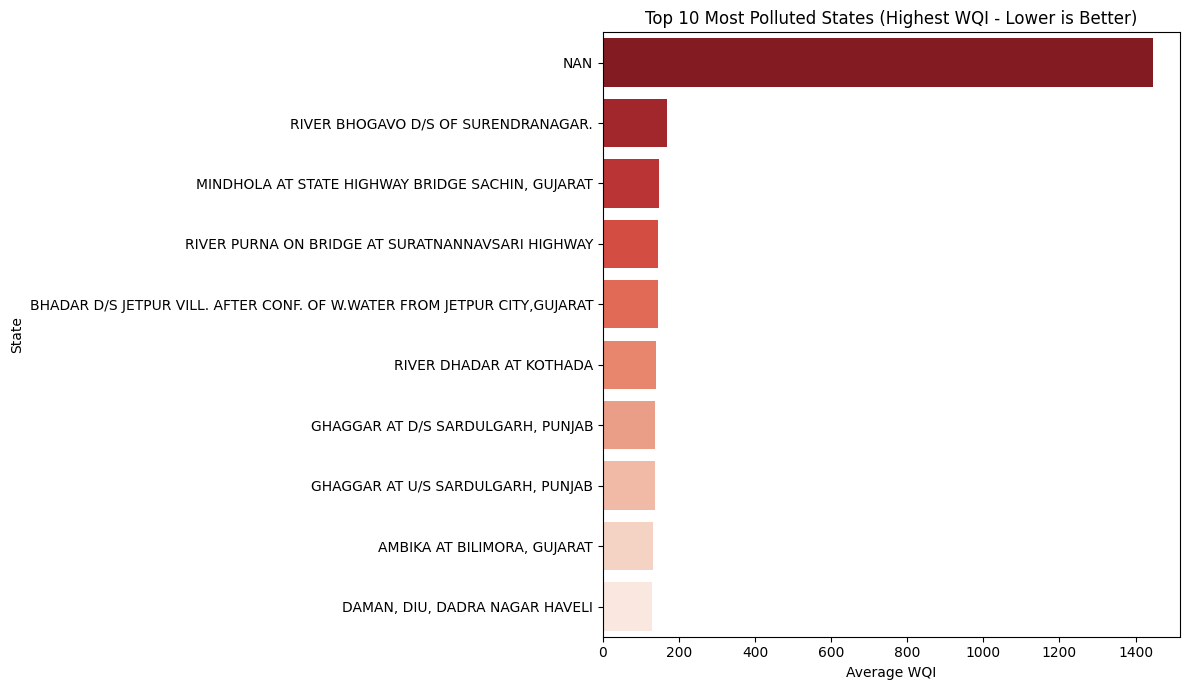

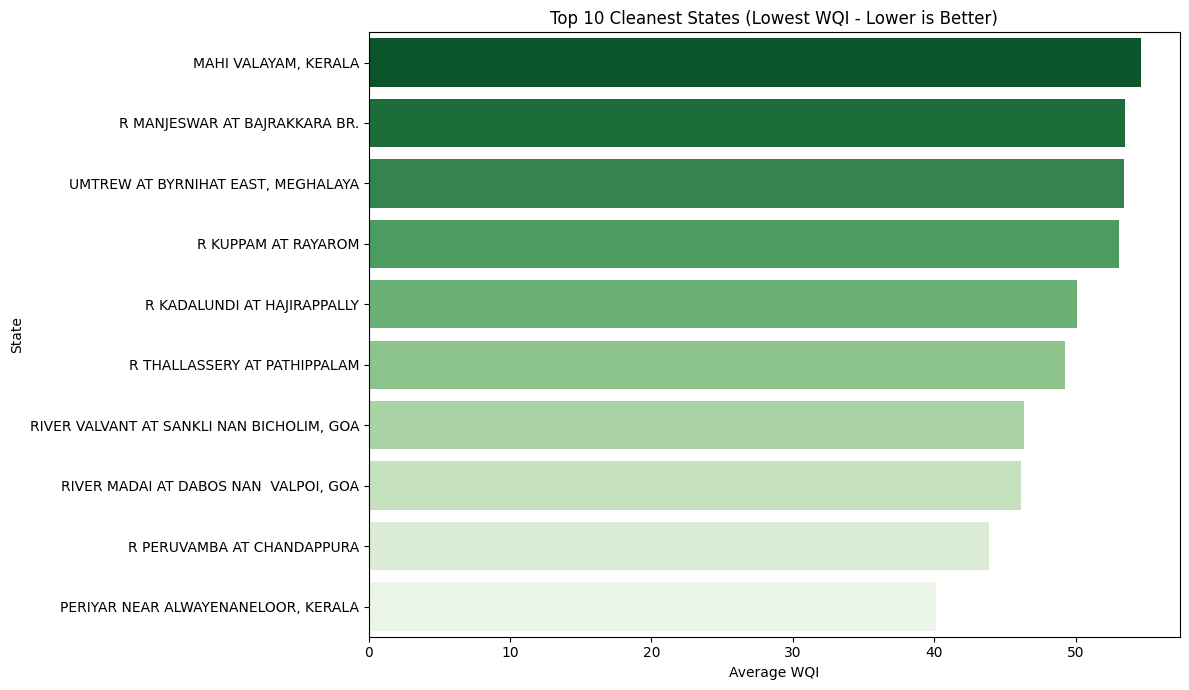

In [68]:
# 3. State-wise Water Quality: Top 10 Polluted States
plt.figure(figsize=(12, 7))
sns.barplot(x=df_wqi_state.head(10).values, y=df_wqi_state.head(10).index, palette='Reds_r')
plt.title('Top 10 Most Polluted States (Highest WQI - Lower is Better)')
plt.xlabel('Average WQI')
plt.ylabel('State')
plt.tight_layout()
plt.show()

# 3. State-wise Water Quality: Top 10 Cleanest States
plt.figure(figsize=(12, 7))
sns.barplot(x=df_wqi_state.tail(10).values, y=df_wqi_state.tail(10).index, palette='Greens_r')
plt.title('Top 10 Cleanest States (Lowest WQI - Lower is Better)')
plt.xlabel('Average WQI')
plt.ylabel('State')
plt.tight_layout()
plt.show()

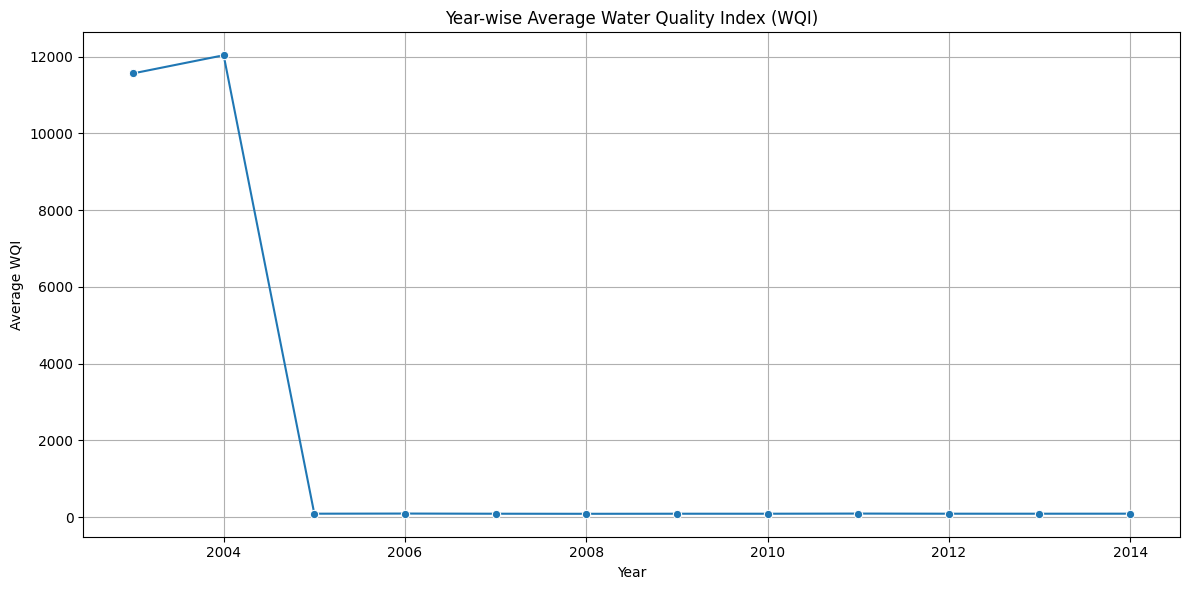

In [69]:
# 4. Year-wise Trend (Line Chart)
plt.figure(figsize=(12, 6))
sns.lineplot(x=df_wqi_year.index, y=df_wqi_year.values, marker='o')
plt.title('Year-wise Average Water Quality Index (WQI)')
plt.xlabel('Year')
plt.ylabel('Average WQI')
plt.grid(True)
plt.tight_layout()
plt.show()

In [74]:
# 5. Pollution Hotspots (Top Polluted Locations)
df_hotspots = df.sort_values(
    "WQI",
    ascending=False
).head(10)

print("\nTop 10 Most Polluted Locations (Highest WQI):\n")
display(df_hotspots[['Location', 'State', 'WQI']])


Top 10 Most Polluted Locations (Highest WQI):



,Location,State,WQI
1953,"IRUPANAM, KERALA",NAN,121231.016444
1936,"PAMBA AT KALLOOPARA, KERALA",NAN,65656.385604
1919,"AMBIKA AT BILIMORA, GUJARAT",NAN,61089.302449
1926,"PERIYAR AT ALWAYE, KERALA",NAN,56477.310201
1918,RIVER DHADAR AT KOTHADA,NAN,46597.716315
1920,"KOLAK AT PATALIA BDG., GUJARAT",NAN,41972.801050
1923,BHADAR D/S JETPUR VILL. AFTER CONF. OF W.WATER...,NAN,41002.182385
1978,"ARASALAR RIVER KARAIKAL REGION, PONDICHERRY",NAN,34900.419358
1986,"TAMBIRAPARANI AT ARUMUGANERI, TAMILNADU",NAN,26291.370965
1924,"MINDHOLA AT STATE HIGHWAY BRIDGE SACHIN, GUJARAT",NAN,20980.848926


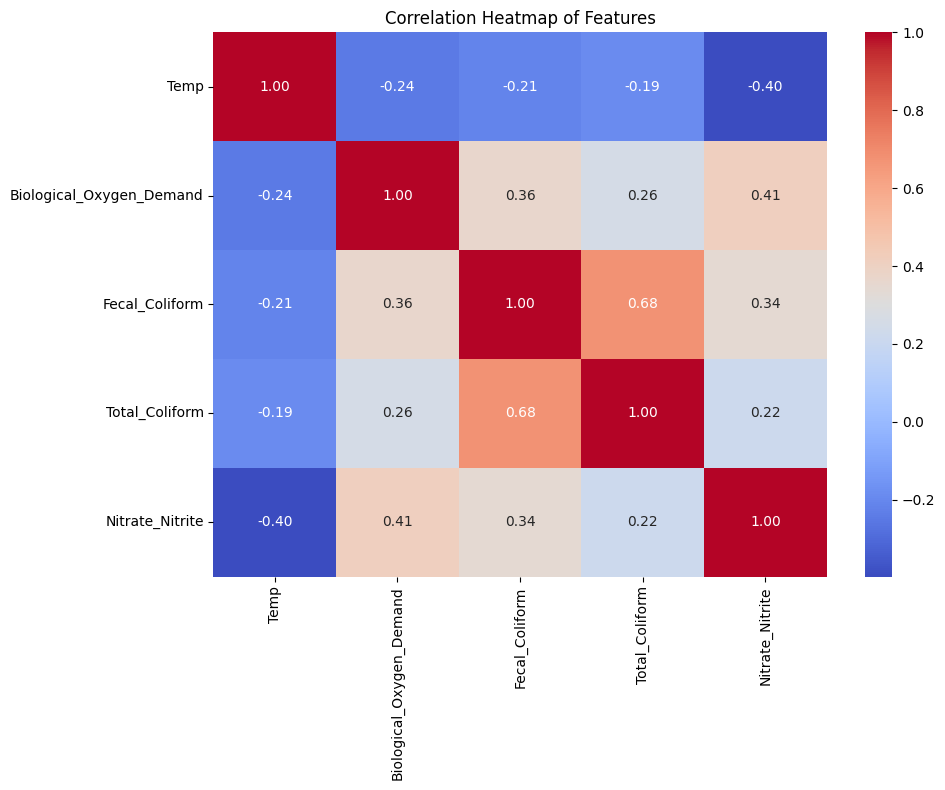

In [71]:
# 6. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df[feature_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Features')
plt.tight_layout()
plt.show()

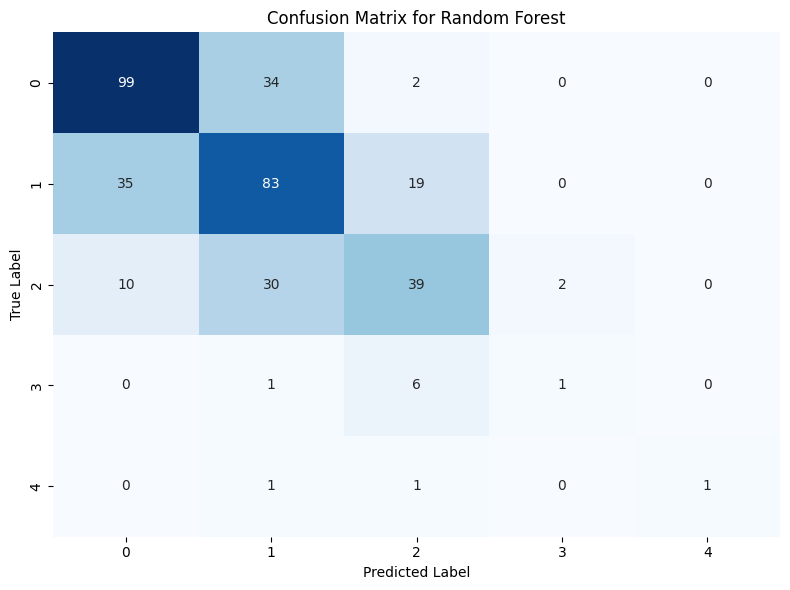

In [72]:
# 7. Confusion Matrix (for the best model)
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(8, 6))

# Predict using the best model
# Need to handle scaled vs unscaled data based on the best_model_name
if best_model_name == "Logistic Regression":
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [76]:
import joblib

joblib.dump(best_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [77]:
! pip install gradio
! pip install plotly
! pip install pandas
! pip install joblib

In [88]:
import gradio as gr
import pandas as pd
import numpy as np
import joblib
import plotly.express as px

# Load model and scaler
model = joblib.load("model.pkl")
# scaler = joblib.load("scaler.pkl") # Not directly needed for RandomForest prediction

# Define the actual feature columns used by the model
# From kernel state: feature_cols: ['Temp', 'Biological_Oxygen_Demand', 'Fecal_Coliform', 'Total_Coliform', 'Nitrate_Nitrite']
model_feature_cols = ['Temp', 'Biological_Oxygen_Demand', 'Fecal_Coliform', 'Total_Coliform', 'Nitrate_Nitrite']

# Prediction Function
def predict_water_quality(
    temp,
    biological_oxygen_demand,
    fecal_coliform,
    total_coliform,
    nitrate_nitrite
):
    features_input = np.array([
        [
            temp,
            biological_oxygen_demand,
            fecal_coliform,
            total_coliform,
            nitrate_nitrite
        ]
    ])

    # The 'best_model_name' is 'Random Forest', which was trained on unscaled data (X_train).
    # So, no scaling is applied to features_input here.
    prediction_class = model.predict(features_input)[0]

    # WQI_Class mapping:
    # 4: 0-25 (Excellent)
    # 3: 26-50 (Good)
    # 2: 51-75 (Poor)
    # 1: 76-100 (Very Poor)
    # 0: >100 (Unsuitable for Drinking)

    status_map = {
        4: "🟢 Excellent Water Quality (WQI <= 25)",
        3: "🟢 Good Water Quality (25 < WQI <= 50)",
        2: "🟡 Poor Water Quality (50 < WQI <= 75)",
        1: "🔴 Very Poor Water Quality (75 < WQI <= 100)",
        0: "🔴 Unsuitable for Drinking (WQI > 100)"
    }
    status = status_map.get(prediction_class, "Unknown Quality")

    return f"""
### Predicted WQI Class: {prediction_class}
{status}
"""

# Plot functions (these rely on the global `df` which should be processed by cell 89c65bbe)
def get_wqi_distribution_plot():
    fig = px.histogram(
        df,
        x="WQI",
        title="Water Quality Index Distribution"
    )
    return fig

def get_state_wqi_plot():
    state_avg = (
        df.groupby("State")["WQI"]
          .mean()
          .sort_values()
    )
    fig = px.bar(
        state_avg,
        orientation="h",
        title="Average WQI by State"
    )
    return fig

def get_polluted_locations_plot():
    worst_locations = (
        df.groupby("Location")["WQI"]
          .mean()
          .sort_values(ascending=False) # Top polluted means highest WQI
          .head(15) # Show top 15 as an example
    )
    fig = px.bar(
        worst_locations,
        orientation="h",
        title="Most Polluted Locations (Top 15)"
    )
    return fig

# Interface
with gr.Blocks(
    title="Water Quality Intelligence System"
) as demo:
    gr.Markdown(
        """
        # 💧 Water Quality Intelligence System

        Predict Water Quality Index using Machine Learning

        Built for Environmental Monitoring and Pollution Assessment
        """
    )

    with gr.Tabs():
        with gr.TabItem("Prediction"): # Prediction tab
            gr.Markdown("## Predict Water Quality Class")
            with gr.Row():
                temp = gr.Slider(0, 50, value=25, label="Temperature (Temp)")
                biological_oxygen_demand = gr.Slider(0, 30, value=5, label="Biological Oxygen Demand (BOD)")
            with gr.Row():
                fecal_coliform = gr.Slider(0, 10000, value=1000, label="Fecal Coliform")
                total_coliform = gr.Slider(0, 100000, value=5000, label="Total Coliform")
            with gr.Row():
                nitrate_nitrite = gr.Slider(0, 100, value=20, label="Nitrate_Nitrite")

            predict_btn = gr.Button("Predict Water Quality Class")
            output = gr.Markdown()

            predict_btn.click(
                predict_water_quality,
                inputs=[
                    temp,
                    biological_oxygen_demand,
                    fecal_coliform,
                    total_coliform,
                    nitrate_nitrite
                ],
                outputs=output
            )

        with gr.TabItem("Data Insights"): # Data Insights tab
            gr.Markdown("## Key Data Insights")
            gr.Markdown("### Water Quality Index Distribution")
            gr.Plot(get_wqi_distribution_plot())

            gr.Markdown("### Average WQI by State")
            gr.Plot(get_state_wqi_plot())

        with gr.TabItem("Pollution Hotspots"): # Pollution Hotspots tab
            gr.Markdown("## Pollution Hotspots")
            gr.Markdown("### Top 15 Most Polluted Locations (Highest WQI)")
            gr.Plot(get_polluted_locations_plot())

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3015ddfe40f0c6b358.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [79]:
with gr.Tabs():

    with gr.Tab("Prediction"):
        ...

    with gr.Tab("Data Insights"):
        ...

    with gr.Tab("Pollution Hotspots"):
        ...

In [89]:
import plotly.express as px

fig = px.histogram(
    df,
    x="WQI",
    title="Water Quality Distribution"
)

gr.Plot(fig)

In [90]:
state_avg = (
    df.groupby("State")["WQI"]
      .mean()
      .sort_values()
)

fig = px.bar(
    state_avg,
    orientation="h",
    title="Average WQI by State"
)

gr.Plot(fig)

In [91]:
worst_locations = (
    df.groupby("Location")["WQI"]
      .mean()
      .sort_values()
      .head(15)
)

fig = px.bar(
    worst_locations,
    orientation="h",
    title="Most Polluted Locations"
)

gr.Plot(fig)